[reference](https://www.ipac26.org/prepress/pdf/MOP6318.pdf)

change everything to torch float64

In [1]:
# unify the data type into torch.float64
import torch
torch.set_default_dtype(torch.float64)   
print("default dtype:", torch.get_default_dtype())  

# cease warnings
import warnings

warnings.filterwarnings(
    "ignore", 
    message=".*'where' used without 'out'.*", 
    category=UserWarning, 
    module="scipy.optimize._trustregion_constr"
)

warnings.filterwarnings(
    "ignore", 
    message=".*delta_grad == 0.0.*", 
    category=UserWarning, 
    module="scipy.optimize._differentiable_functions"
) 

default dtype: torch.float64


In [2]:
%load_ext autotime

# ── 0. Imports & path setup ─────────────────────────────────────────
import sys, os, copy, time, warnings
# sys.path.insert(0, "/home/niels/FELsim_clone/backend")
CURRENT_DIR = os.getcwd()
BACKEND_DIR = CURRENT_DIR if os.path.basename(CURRENT_DIR) == "backend" else os.path.abspath(os.path.join(CURRENT_DIR, "../backend"))
sys.path.insert(0, BACKEND_DIR)
print(BACKEND_DIR)
os.makedirs(os.path.join(CURRENT_DIR, "../results"), exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from evolutionPlotter import EvolutionPlotter
from felsimAdapter import FELsimAdapter

# ── Shared constants ─────────────────────────────────────────────────
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
EXCEL_PATH  = os.path.abspath(os.path.join(CURRENT_DIR, "../beam_excel/Beamline_elements_3.xlsx"))


BEAM_ENERGY    = 40.0    # MeV as the energy for a single electron
N_PARTICLES    = 1000    # number of electrons in the beam for simulation
SEED           = 42      # random seed for reproducibility
CURRENT_BOUNDS = (0.01, 1.5)   # current bound in the experiment heuristically

# ── Relativistic factors ─────────────────────────────────────────────
relat = lattice(1, fringeType=None)
relat.setE(E=BEAM_ENERGY)       # set the energy of the relativistic factor
GAMMA_REL = relat.gamma         # Lorentz factor as the mass ratio of the electron and the static electron
BETA_REL  = relat.beta          # standardized electron velocity
NORM      = GAMMA_REL * BETA_REL # electron momentom ratio between the current electron and the static one

# ── Undulator matching targets (MkV FEL, K=1.2, λ_u=2.3 cm) ─────────
K        = 1.2      # Undulator Parameter
LAMBDA_U = 2.3e-2   # wavelength, unit: m
## twiss parameters
BETA_YM  = GAMMA_REL / (K * 2 * np.pi / LAMBDA_U)   # matched β_y at UND entrance, beam size in y direction
BETA_XM  = 1.4       # m  — matched β_x at UND entrance, beam size at the x direction
ALPHA_XM = 0.47      # — Courant-Snyder α_x at UND entrance, beam size converge at the direction x
ALPHA_YM = 0.0       # — Courant-Snyder α_y at UND entrance, beam waist is achieved at the y direction

print(f"γ = {GAMMA_REL:.4f},  β = {BETA_REL:.6f},  βγ = {NORM:.4f}")
print(f"Matched β_ym = {BETA_YM:.4f} m   (K={K}, λ_u={LAMBDA_U*100:.1f} cm)")
print(f"Matched β_xm = {BETA_XM:.4f} m,  α_xm = {ALPHA_XM:.4f},  α_ym = {ALPHA_YM:.4f}")


c:\Users\yilu2\my_files\research\FELsim\backend
γ = 79.2794,  β = 0.999920,  βγ = 79.2731
Matched β_ym = 0.2418 m   (K=1.2, λ_u=2.3 cm)
Matched β_xm = 1.4000 m,  α_xm = 0.4700,  α_ym = 0.0000
time: 4.92 s (started: 2026-06-05 15:05:14 -10:00)


## 1 — Beam Distribution
Physics-based 6D Gaussian matching the UH linac reference parameters.


In [3]:
%load_ext autotime

# ── Beam parameters ─────────────────────────────────────────────────
epsilon_n         = 8.0      # π·mm·mrad  normalised emittance, inner attribute of electron gun
x_std             = 0.8      # mm, initial standard deviation at x direction
y_std             = 0.8      # mm, initial standard deviation at y direction
f_RF              = 2856e6   # Hz, acceleration frequency
bunch_spread_ps   = 2.0      # ps, beam length
energy_spread_pct = 0.5      # %, energy standard deviation inside the beam
h                 = 5e9      # 1/s  chirp, longitudinal chirp for beam compression

epsilon     = epsilon_n / NORM # geometric emittance
x_prime_std = epsilon / x_std # alpha_x=0 at the initial point, so that sigma_x * sigma_x'=epsilon
y_prime_std = epsilon / y_std # alpha_y=0 at the initial point, so that sigma_y * sigma_y'=epsilon
tof_std     = bunch_spread_ps * 1e-9 * f_RF # Time of Flight Standard Deviation, change from cycle to mili-cycle, measuring how much the electron bunch occupies the cycle
energy_std  = energy_spread_pct * 10 # transform from percent to per mill

ebeam_obj = ebeam_class()
dtype=torch.float64
PARTICLES = ebeam_obj.gen_6d_gaussian(
    0,
    [x_std, x_prime_std, y_std, y_prime_std, tof_std, energy_std],
    N_PARTICLES,
    dtype=dtype
)
# Apply longitudinal chirp
PARTICLES[:, 5] += h * (PARTICLES[:, 4] / f_RF)

print(f"ε = {epsilon:.5f} π·mm·mrad  (geometric)")
print(f"σ_x={x_std:.2f} mm, σ_x'={x_prime_std:.5f} mrad")
print(f"σ_y={y_std:.2f} mm, σ_y'={y_prime_std:.5f} mrad")
print(f"Particles: {PARTICLES.shape}")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
ε = 0.10092 π·mm·mrad  (geometric)
σ_x=0.80 mm, σ_x'=0.12615 mrad
σ_y=0.80 mm, σ_y'=0.12615 mrad
Particles: torch.Size([1000, 6])
time: 16 ms (started: 2026-06-05 15:05:19 -10:00)


## 2 — Beamline & Element Index Map
The `ExcelElements` parser produces **138 FELsim elements**. Key reference indices:
| Location | FELsim idx | z (m) | Physical meaning |
|---|---|---|---|
| End of 1st doublet region | 8–9 | ≈0.73–1.0 | First α targets |
| IP (focus) | 59 | ≈7.11 | Minimum envelope |
| UND entrance | 117 | ≈12.39 | Undulator matching |


In [5]:
%load_ext autotime

# ── Load beamline & map quad indices ───────────────────────────────
beamline_full = ExcelElements(EXCEL_PATH).create_beamline()
print(f"FELsim elements: {len(beamline_full)}")

s = 0.0
quad_info = []
for i, e in enumerate(beamline_full):
    cls = e.__class__.__name__
    L   = float(getattr(e, 'length', 0.0) or 0.0)
    if cls in ('qpfLattice', 'qpdLattice'):
        quad_info.append((i, cls, round(s, 5), round(s+L, 5),
                          round(float(getattr(e, 'current', 0) or 0), 5)))
    s += L

quad_indices = [q[0] for q in quad_info]
df_quads = pd.DataFrame(quad_info, columns=['idx','type','s_start','s_end','current_A'])
print(f"Quadrupoles: {len(quad_indices)}")
print(df_quads.to_string(index=False))

# ── Gold-standard currents from Eremey's FELsim S1 solution ─────────
FELSIM_S1_CURRENTS = {
     1: 0.8218,  3: 1.0430,
    10: 3.8834,
    16: 2.2396, 18: 4.9532, 20: 3.4258,
    27: 4.6657,
    33: 2.6942, 35: 2.6523, 37: 0.2768, 39: 0.2768, 41: 2.6523, 43: 2.6942,
    50: 4.6739,
    56: 3.1219, 58: 3.3129,
    61: 5.1775, 63: 4.0434,
    70: 4.6818,
    76: 3.9336, 78: 4.0787, 80: 0.0139,
    87: 1.3624, 93: 0.9452, 95: 2.8851, 97: 2.1921,
}
print(f"\nFELSIM_S1_CURRENTS: {len(FELSIM_S1_CURRENTS)} quadrupoles loaded")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
FELsim elements: 138
Quadrupoles: 26
 idx       type  s_start    s_end  current_A
   1 qpfLattice  0.35878  0.44768    0.88572
   3 qpdLattice  0.64453  0.73342    1.05289
  10 qpfLattice  2.03304  2.12194    3.81660
  16 qpdLattice  2.73535  2.82425    2.57981
  18 qpfLattice  2.86743  2.95633    4.56570
  20 qpdLattice  2.99951  3.08841    2.57981
  27 qpfLattice  3.55448  3.64338    4.49146
  33 qpdLattice  4.15187  4.24077    1.59614
  35 qpfLattice  4.29157  4.38047    3.08092
  37 qpdLattice  4.43127  4.52017    1.59614
  39 qpdLattice  4.93513  5.02403    1.59614
  41 qpfLattice  5.07483  5.16373    3.08092
  43 qpdLattice  5.21453  5.30343    1.59614
  50 qpfLattice  5.83098  5.91988    4.49072
  56 qpdLattice  6.36946  6.45836    2.25575
  58 qpfLattice  6.55775  6.64665    1.67186
  61 qpfLattice  7.32562  7.41452    0.02487
  63 qpdLattice  7.46992  7.55882    0.00100
  70 qpfLattice  8.10749

In [6]:
%load_ext autotime

# ── Confirm key reference positions ────────────────────────────────
s = 0.0
for i, e in enumerate(beamline_full):
    s += float(getattr(e, 'length', 0.0) or 0.0)
    if i in (8, 9, 15, 25, 32, 37, 55, 59, 92, 117):
        print(f"  el {i:3d}  {e.__class__.__name__:20s}  s_end={s:.5f} m")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
  el   8  dipole_wedge          s_end=1.80682 m
  el   9  driftLattice          s_end=2.03304 m
  el  15  driftLattice          s_end=2.73535 m
  el  25  dipole_wedge          s_end=3.34855 m
  el  32  driftLattice          s_end=4.15187 m
  el  37  qpdLattice            s_end=4.52017 m
  el  55  driftLattice          s_end=6.36946 m
  el  59  driftLattice          s_end=7.11013 m
  el  92  driftLattice          s_end=10.21208 m
  el 117  driftLattice          s_end=12.39158 m
time: 0 ns (started: 2026-06-05 15:05:19 -10:00)


## 3 — Statistical Benchmark Infrastructure

`run_benchmark()` runs the same scenario `N_RUNS` times from different random starting currents.  
`plot_stat_convergence()` plots **mean ± 1σ RMS bands** — the same visual style as Eremey's
reference convergence figures.


In [48]:
%load_ext autotime

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def method_label(method, label=None):
    if label:
        return label
    if isinstance(method, str):
        return method
    return getattr(method, "__name__", str(method))

# ── Benchmark runner ────────────────────────────────────────────────
def run_benchmark(scenario_name, beamline_slice_len, particles, seg_var, obj, bounds,
                  method, n_runs=5, SEED=42, seed_offset=0, jac=None, options=None, verbose=True, method_tag=None):
    """Run beamOptimizer.calc() n_runs times from uniform-random starting currents."""
    var_names = list({seg_var[i][0] for i in seg_var})
    results   = []
    method_name = method_label(method, method_tag)

    for run_i in range(n_runs):
        bl = ExcelElements(EXCEL_PATH).create_beamline()[:beamline_slice_len]
        p  = particles.clone()
        rng = np.random.default_rng(SEED + seed_offset + run_i * 997)
        sp  = {v: {"bounds": bounds[v],
                   "start": float(rng.uniform(bounds[v][0], bounds[v][1]))}
               for v in var_names}
        start_x = {v: sp[v]["start"] for v in var_names}
        obj_copy = copy.deepcopy(obj)
        opti = beamOptimizer(bl, p)
        t0   = time.perf_counter()

        try:
            res  = opti.calc(method, seg_var, sp, obj_copy, jac=jac, options=options,
                             printResults=False, plotProgress=False)
            wall = time.perf_counter() - t0

            result_x_dict = dict(zip(var_names, res.x))
            i_1 = result_x_dict.get("I", np.nan)
            i_3 = result_x_dict.get("I2", np.nan)

            def safe_get_measured(idx):
                if idx in opti.objectives and len(opti.objectives[idx]) > 0:
                    val = opti.objectives[idx][0].get("measured", np.nan)
                    return float(val.item() if hasattr(val, 'item') else val)
                return np.nan

            alpha_x = safe_get_measured(8)
            alpha_y = safe_get_measured(9)

            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float(res.fun),
                "nfev": int(getattr(res,'nfev',len(opti.plotMSE))),
                "nit": int(getattr(res,'nit',-1)),
                "wall_time": round(wall,3),
                "mse_curve": list(opti.plotMSE), "success": bool(res.success),
                "start_x": start_x, "result_x": result_x_dict,
                "I_1": i_1, "I_3": i_3, "alpha_x": alpha_x, "alpha_y": alpha_y
            })
        except Exception as exc:
            wall = time.perf_counter() - t0
            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float("nan"), "nfev": -1, "nit": -1,
                "wall_time": round(wall,3), "mse_curve": [], "success": False,
                "start_x": start_x, "result_x": {}, "error": str(exc),
                "I_1": np.nan, "I_3": np.nan, "alpha_x": np.nan, "alpha_y": np.nan
            })
            if verbose: print(f"  {method_name} run {run_i+1} FAILED: {exc}")
            continue
        if verbose:
            print(f"  {method_name:22s}  run {run_i+1}/{n_runs}  "
                  f"MSE={results[-1]['final_mse']:.3e}  nit={results[-1]['nit']:<3} "
                  f"nfev={results[-1]['nfev']:<4} t={wall:.2f}s")
    return results

def results_to_df(results_list):
    keep = ('run','method','scenario','method_tag','final_mse','nfev','nit',
            'wall_time','success', 'I_1', 'I_3', 'alpha_x', 'alpha_y')
    return pd.DataFrame([{k: r[k] for k in keep if k in r} for r in results_list])

def plot_stat_convergence(results_by_tag, title="Convergence", figsize=None,
                          colors=None, ax=None, save_path=None, scale="log",
                          convergence_epsilon=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=figsize or (7, 4.5))
    else: fig = ax.get_figure()

    try:
        cmap = plt.colormaps.get_cmap("tab10")
    except AttributeError:
        cmap = plt.get_cmap("tab10")

    if colors is None: colors = [cmap(i) for i in range(len(results_by_tag))]

    legend_handles = []
    for (tag, res_list), col in zip(results_by_tag.items(), colors):
        n_t = len(res_list)

        if convergence_epsilon is None:
            converged_iter = [r for r in res_list if r.get('mse_curve')]
        else:
            converged_iter = [r for r in res_list
                    if r.get('mse_curve')
                    and np.isfinite(r['mse_curve'][-1])
                    and r['mse_curve'][-1] < convergence_epsilon]

        n_s = len(converged_iter)
        curves = [r['mse_curve'] for r in converged_iter]

        if not curves:
            legend_handles.append(Line2D([0], [0], color=col, linewidth=2,
                                         label=f"{tag}  (0/{n_t} converged)"))
            continue

        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves], dtype=np.float64)

        padded = np.clip(padded, a_min=1e-20, a_max=1e100)

        evals = np.arange(1, max_len + 1)

        log_padded = np.log10(padded)
        log_mean   = np.mean(log_padded, axis=0)
        log_std    = np.std(log_padded,  axis=0)
        mean       = 10 ** log_mean
        band_lower = 10 ** (log_mean - log_std)
        band_upper = 10 ** (log_mean + log_std)

        ax.plot(evals, mean, color=col, linewidth=2.0, zorder=3)
        ax.fill_between(evals, np.maximum(band_lower, 1e-20), band_upper,
                        color=col, alpha=0.20, zorder=2)

        legend_handles.append(Line2D([0], [0], color=col, linewidth=2,
                                     label=f"{tag}  ({n_s}/{n_t} converged)"))

    ax.set_yscale(scale)
    ax.set_xlabel('Function evaluations (Forward Passes)', fontsize=11)
    ax.set_ylabel('Normalised MSE', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=9)
    if standalone:
        fig.tight_layout()
        if save_path: fig.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
    return ax
print("Benchmark helpers loaded (Warnings Suppressed).")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Benchmark helpers loaded (Warnings Suppressed).
time: 172 ms (started: 2026-06-07 21:17:44 -10:00)


---
## 4 — Scenario A: Doublet (2 quadrupoles)

**Exact replication of Stage 1 from `beamline_optimization.ipynb`:**
α_x = α_y = 0 at elements 8–9 (s ≈ 0.73–1.0 m).

Simple 2D problem — validates all methods and compares FELsim vs COSY timing.


In [49]:
def run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS, A_BEAMLINE_LEN, METHODS_A, SEED=42, scale="log", options=None, METHOD_OPTIONS={}):
    A_BOUNDS      = {"I": CURRENT_BOUNDS, "I2": CURRENT_BOUNDS}
    REF_I_1 = REF_I[0]
    REF_I_3 = REF_I[1]
    results_A = {}
    for method_spec in METHODS_A:
        if len(method_spec) == 3:
            method, jac, label = method_spec
        else:
            method, jac = method_spec
            label = None
        options = METHOD_OPTIONS.get(method_label(method, label), None) 
        method_name = method_label(method, label)
        tag = method_name + (r"$+\nabla f$" if jac else "")
        if method_name=="trust-constr":
            tag = method_name + r"$$"
        try:
            from IPython.display import Markdown, display
            display(Markdown(f"### Scenario A — {tag}  ({N_RUNS_A} runs)"))
        except Exception:
            print(f"\n▶ Scenario A — {tag}  ({N_RUNS_A} runs)")

        # Execute benchmark (Note: passing 'jac' here prepares for PyTorch analytical gradients later)
        res = run_benchmark(
            "A",
            A_BEAMLINE_LEN,
            PARTICLES,
            A_VARS,
            A_OBJ,
            A_BOUNDS,
            method=method,
            n_runs=N_RUNS_A,
            SEED=SEED,
            seed_offset=0,
            jac=jac,
            options=options,
            method_tag=method_name,
        )
        for r in res:
            r["method_tag"] = tag
        results_A[tag] = res

    # Flatten and merge nested results into a single DataFrame
    df_A = results_to_df([r for v in results_A.values() for r in v])

    # ==============================================================================
    # 🎯 CORE FIX: Patch the bug where derivative-free algorithms return negative iterations
    # ==============================================================================
    # Since derivative-free algorithms lack internal line searches, their number
    # of function evaluations (nfev) is mathematically equivalent to their true exploration steps (nit).
    # If iteration count < 0 is detected, directly extract 'nfev' as the true iteration count!
    if 'nit' in df_A.columns and 'nfev' in df_A.columns:
        df_A.loc[df_A['nit'] < 0, 'nit'] = df_A.loc[df_A['nit'] < 0, 'nfev']

    print("\n" + "="*115)
    print(f" 🎯 SCENARIO A: Robustness (Tol < {EPSILON}) & Discovered Physics State vs Reference")
    print("="*115)

    # 1. Core Evaluation: Check if each run successfully converged below the target MSE threshold
    df_A['is_converged'] = df_A['final_mse'] < EPSILON

    # 2. Calculate average performance metrics
    def _geom_mean_converged(s):
        conv = s[s < EPSILON]
        return 10 ** np.log10(conv).mean() if len(conv) else np.nan
    # (🎯 Note: The redundant 'nfev_mean' has been completely removed as requested)
    summary_stats = df_A.groupby('method_tag').agg(
        conv_rate=('is_converged', 'mean'),
        nit_mean=('nit', 'mean'),
        nfev_mean=('nfev', 'mean'),
        wall_time_mean=('wall_time', 'mean'),
    ).join(
        df_A.groupby('method_tag')['final_mse']
            .apply(_geom_mean_converged)
            .rename('final_mse_mean')
    )

    # 3. Extract the Champion Solution: Find the run with the lowest error for each method,
    #    extracting its exact hardware currents and resulting alpha observables.
    idx_best = df_A.groupby('method_tag')['final_mse'].idxmin()
    best_runs = df_A.loc[idx_best, ['method_tag', 'I_1', 'I_3', 'alpha_x', 'alpha_y']].set_index('method_tag')

    # 4. Merge all statistical data
    final_summary = summary_stats.join(best_runs).reset_index()

    # Inject the expert's gold-standard values to establish the Ground Truth
    final_summary['I_1_ref'] = REF_I_1
    final_summary['I_3_ref'] = REF_I_3

    # Reorder columns: Place the AI-predicted currents right next to the expert's Reference values
    final_summary = final_summary[[
        'method_tag', 'conv_rate', 'nit_mean', 'nfev_mean', 'wall_time_mean',
        'final_mse_mean', 'I_1_ref', 'I_1', 'I_3_ref', 'I_3', 'alpha_x', 'alpha_y'
    ]]

    # 5. Plain text formatted output to bypass Jupyter HTML rendering bugs (missing tables)
    format_dict = {
        'conv_rate': '{:.0%}',
        'nit_mean': '{:.1f}',
        'nfev_mean': '{:.1f}',
        'wall_time_mean': '{:.3f} s',
        'final_mse_mean': '{:.2e}',
        'I_1_ref': '{:.4f} A',
        'I_1': '{:.4f} A',
        'I_3_ref': '{:.4f} A',
        'I_3': '{:.4f} A',
        'alpha_x': '{:.2e}',
        'alpha_y': '{:.2e}'
    }

    formatted_df = final_summary.copy()

    # Apply formatting conversions in bulk
    for col, fmt in format_dict.items():
        if col in formatted_df.columns:
            formatted_df[col] = formatted_df[col].apply(lambda x: fmt.format(x) if pd.notna(x) else "NaN")

    # Print the final beautifully aligned data table
    print(formatted_df.to_string(index=False, justify='center'))
    print("="*115)

    # Plot the final algorithm stability curve
    plot_stat_convergence(
        results_A,
        title=f"Scenario A: Convergence Stability (Target MSE < {EPSILON})",
        convergence_epsilon=EPSILON,
        scale=scale
    )
    return results_A, df_A, final_summary

time: 31 ms (started: 2026-06-07 21:17:48 -10:00)


In [50]:
%load_ext autotime
def display_results(results_A, REF_I):
        
    # ── Scenario A — Best optimised quadrupole currents per method ─────
    print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
    print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
    print("─" * 58)
    for tag, res_list in results_A.items():
        valid = [r for r in res_list
                if r.get('result_x') and not np.isnan(r['final_mse'])]
        if not valid:
            print(f"  {tag:<20}  no valid run")
            continue
        best = min(valid, key=lambda r: r['final_mse'])
        I  = best['result_x'].get('I',  float('nan'))
        I2 = best['result_x'].get('I2', float('nan'))
        print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
    print()
    print(f"  Reference FELsim S1 currents: I={REF_I[0]:.4f} A,  I2={REF_I[1]:.4f} A")
    # Mean best across all runs
    all_valid = [r for v in results_A.values() for r in v
                if r.get('result_x') and not np.isnan(r['final_mse'])]
    if all_valid:
        best_overall = min(all_valid, key=lambda r: r['final_mse'])
        print(f"\n  Overall best across all methods/runs:")
        print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
        print(f"    I={best_overall['result_x']['I']:.5f} A,  "
            f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 16 ms (started: 2026-06-07 21:17:49 -10:00)


In [51]:
# check default setting for each method
import inspect

import scipy.optimize._lbfgsb_py as lbfgsb
import scipy.optimize._optimize as optimize_core
import scipy.optimize._slsqp_py as slsqp
import scipy.optimize._cobyla_py as cobyla
from scipy.optimize._trustregion_constr import minimize_trustregion_constr as trust_constr

MINIMIZER_FUNCS = {
    "L-BFGS-B": lbfgsb._minimize_lbfgsb,
    "Nelder-Mead": optimize_core._minimize_neldermead,
    "SLSQP": slsqp._minimize_slsqp,
    "trust-constr": trust_constr._minimize_trustregion_constr,
    "COBYLA": cobyla._minimize_cobyla,
}

for method_name, minimize_func in MINIMIZER_FUNCS.items():
    print(f"\n## {method_name}")
    print(minimize_func.__doc__)
    print(inspect.signature(minimize_func))


## L-BFGS-B

    Minimize a scalar function of one or more variables using the L-BFGS-B
    algorithm.

    Options
    -------
    disp : None or int
        Deprecated option that previously controlled the text printed on the
        screen during the problem solution. Now the code does not emit any
        output and this keyword has no function.

        .. deprecated:: 1.15.0
            This keyword is deprecated and will be removed from SciPy 1.18.0.

    maxcor : int
        The maximum number of variable metric corrections used to
        define the limited memory matrix. (The limited memory BFGS
        method does not store the full hessian but uses this many terms
        in an approximation to it.)
    ftol : float
        The iteration stops when ``(f^k -
        f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol``.
    gtol : float
        The iteration will stop when ``max{|proj g_i | i = 1, ..., n}
        <= gtol`` where ``proj g_i`` is the i-th component of the
        project

In [ ]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1e-3

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 3
A_BEAMLINE_LEN = 10

# this is default version
METHOD_OPTIONS = {
    "L-BFGS-B": {
        "maxcor": 10,
        "ftol": 2.220446049250313e-09,
        "gtol": 1e-5,
        "eps": 1e-8,
        "maxfun": 15000,
        "maxiter": 15000,
        "maxls": 20,
    },
    "SLSQP": {
        "maxiter": 100,
        "ftol": 1e-6,
        "iprint": 1,
        "disp": False,
        "eps": 1.4901161193847656e-08,
        "finite_diff_rel_step": None,
        "workers": None,
    },
    "trust-constr": {
        "xtol": 1e-8,
        "gtol": 1e-8,
        "barrier_tol": 1e-8,
        "sparse_jacobian": None,
        "maxiter": 1000,
        "verbose": 0,
        "finite_diff_rel_step": None,
        "initial_constr_penalty": 1.0,
        "initial_tr_radius": 1.0,
        "initial_barrier_parameter": 0.1,
        "initial_barrier_tolerance": 0.1,
        "factorization_method": None,
        "disp": False,
        "workers": None,
    },
    "Nelder-Mead": {
        "maxiter": None,
        "maxfev": None,
        "disp": False,
        "return_all": False,
        "initial_simplex": None,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "adaptive": False,
    },
    "COBYLA": {
        "rhobeg": 1.0,
        "tol": 1e-4,
        "maxiter": 1000,
        "disp": 0,
        "catol": None,
        "f_target": float("-inf"),
    },
}

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B", "2-point"),
    ("SLSQP", "2-point"),
    ("COBYLA", None),
    ("trust-constr", None),
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}

time: 16 ms (started: 2026-06-07 21:17:53 -10:00)


In [53]:
# # test whether float64 works
# import numpy as np, copy

# print("PARTICLES dtype:", PARTICLES.dtype)

# A_BEAMLINE_LEN = 138
# bl = ExcelElements(EXCEL_PATH).create_beamline()[:A_BEAMLINE_LEN]
# opti = beamOptimizer(bl, PARTICLES.clone())
# opti.calc("Nelder-Mead", A_VARS,
#           {"I":{"bounds":(0.01,1.5),"start":0.5}, "I2":{"bounds":(0.01,1.5),"start":0.5}},
#           copy.deepcopy(A_OBJ), printResults=False)

# print("variablesToOptimize:", opti.variablesToOptimize)

# x = np.array([0.5, 0.5])
# base = opti._optiSpeed(x)
# print(f"\nbase MSE = {base:.6e}")
# print("test:")
# for h in [1e-5, 1e-7, 1e-9, 1e-11]:
#     xp = x.copy(); xp[0] += h
#     diff = opti._optiSpeed(xp) - base
#     print(f"  h={h:.0e}:  ΔMSE={diff:+.3e}   slope≈{diff/h:+.4e}")

PARTICLES dtype: torch.float64


Exception ignored in: <function ZipFile.__del__ at 0x000002AC19CB65C0>
Traceback (most recent call last):
  File "c:\Users\yilu2\programming_lang\Anaconda\envs\felsim\Lib\zipfile.py", line 1908, in __del__
    self.close()
  File "c:\Users\yilu2\programming_lang\Anaconda\envs\felsim\Lib\zipfile.py", line 1910, in close
    def close(self):

KeyboardInterrupt: 


variablesToOptimize: ['I', 'I2']

base MSE = 4.969018e-01
test:
  h=1e-05:  ΔMSE=-3.885e-05   slope≈-3.8847e+00
  h=1e-07:  ΔMSE=-3.885e-07   slope≈-3.8847e+00
  h=1e-09:  ΔMSE=-3.885e-09   slope≈-3.8847e+00
  h=1e-11:  ΔMSE=-3.885e-11   slope≈-3.8847e+00
time: 7min 12s (started: 2026-06-07 21:17:54 -10:00)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (100 runs)
  Nelder-Mead             run 1/100  MSE=1.559e-08  nit=44  nfev=84   t=14.00s
  Nelder-Mead             run 2/100  MSE=9.229e-09  nit=37  nfev=73   t=13.89s
  Nelder-Mead             run 3/100  MSE=9.466e-09  nit=53  nfev=102  t=16.63s
  Nelder-Mead             run 4/100  MSE=3.242e-08  nit=27  nfev=53   t=8.71s
  Nelder-Mead             run 5/100  MSE=2.836e-09  nit=40  nfev=77   t=12.21s
  Nelder-Mead             run 6/100  MSE=2.226e-08  nit=32  nfev=61   t=10.77s
  Nelder-Mead             run 7/100  MSE=2.014e-07  nit=44  nfev=85   t=13.08s
  Nelder-Mead             run 8/100  MSE=6.463e-10  nit=45  nfev=85   t=12.50s
  Nelder-Mead             run 9/100  MSE=3.169e-08  nit=45  nfev=87   t=13.07s
  Nelder-Mead             run 10/100  MSE=4.284e-08  nit=43  nfev=80   t=11.82s
  Nelder-Mead             run 11/100  MSE=2.780e-08  nit=34  nfev=66   t=9.88s
  Nelde

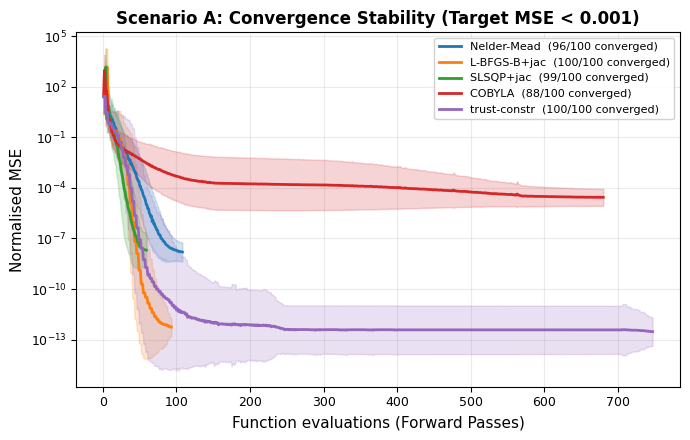

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            6.4634e-10     0.2502     0.2403
  L-BFGS-B+jac           2.6120e-14     0.7512     0.5806
  SLSQP+jac              1.2036e-11     0.2502     0.2403
  COBYLA                 1.1734e-07     0.7511     0.5806
  trust-constr           8.0014e-18     0.7512     0.5806

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: trust-constr,  MSE=8.0014e-18
    I=0.75118 A,  I2=0.58057 A
time: 2h 3min 34s (started: 2026-06-05 15:42:17 -10:00)


In [23]:
%load_ext autotime

results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS, A_BEAMLINE_LEN, METHODS_A,scale="log",METHOD_OPTIONS=METHOD_OPTIONS)
display_results(results_A, REF_I)

In [34]:
# save the results
import pickle

with open(os.path.join(CURRENT_DIR, "../results/scenario_A_results_v3.pkl"), "wb") as f:
    pickle.dump({
        "results_A": results_A,
        "df_A": df_A,
        "final_summary": final_summary
    }, f)
print("Results saved to scenario_A_results_v3.pkl")

     run        method scenario    method_tag     final_mse  nfev  nit  \
0      1   Nelder-Mead        A   Nelder-Mead  1.558643e-08    84   44   
1      2   Nelder-Mead        A   Nelder-Mead  9.229138e-09    73   37   
2      3   Nelder-Mead        A   Nelder-Mead  9.465581e-09   102   53   
3      4   Nelder-Mead        A   Nelder-Mead  3.242282e-08    53   27   
4      5   Nelder-Mead        A   Nelder-Mead  2.836254e-09    77   40   
..   ...           ...      ...           ...           ...   ...  ...   
495   96  trust-constr        A  trust-constr  8.767633e-13    66   28   
496   97  trust-constr        A  trust-constr  5.635462e-12    51   23   
497   98  trust-constr        A  trust-constr  8.765611e-13    63   28   
498   99  trust-constr        A  trust-constr  4.217449e-13    48   24   
499  100  trust-constr        A  trust-constr  7.571811e-14    42   21   

     wall_time  success       I_1       I_3       alpha_x       alpha_y  \
0       13.999     True  0.833853  1

In [39]:
from scipy.optimize import minimize, BFGS, SR1
import numpy as np

def f(x): return (x[0]-1)**2 + (x[1]-2)**2

r_none = minimize(f, [0,0], method='trust-constr', jac=None)              
r_bfgs = minimize(f, [0,0], method='trust-constr', jac='2-point', hess=BFGS()) 

print("hess=None  :", np.round(r_none.x,6), "nit=", r_none.nit, "nfev=", r_none.nfev)
print("hess=BFGS():", np.round(r_bfgs.x,6), "nit=", r_bfgs.nit, "nfev=", r_bfgs.nfev)

hess=None  : [1. 2.] nit= 4 nfev= 12
hess=BFGS(): [1. 2.] nit= 4 nfev= 12
time: 203 ms (started: 2026-06-06 16:17:45 -10:00)


In [45]:
import importlib
import beamOptimizer as beamOptimizer_module  
importlib.reload(beamOptimizer_module)         
from beamOptimizer import beamOptimizer         

time: 94 ms (started: 2026-06-06 17:13:22 -10:00)


In [46]:
import numpy as np, copy, pickle, os, time

bl = ExcelElements(EXCEL_PATH).create_beamline()[:A_BEAMLINE_LEN]
opti = beamOptimizer(bl, PARTICLES.clone())

SP = {"I":  {"bounds": CURRENT_BOUNDS, "start": 0.5},
      "I2": {"bounds": CURRENT_BOUNDS, "start": 0.5}}

def mse_at(i1, i2):
    try:
        v = opti.evaluate([i1, i2], A_VARS, SP, copy.deepcopy(A_OBJ))   
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan

N_GRID = 60
lo, hi = 0.01, 1.5
I1_vals = np.linspace(lo, hi, N_GRID)
I2_vals = np.linspace(lo, hi, N_GRID)
MSE_grid = np.empty((N_GRID, N_GRID))

t0 = time.perf_counter()
for j, i2 in enumerate(I2_vals):
    for i, i1 in enumerate(I1_vals):
        MSE_grid[j, i] = mse_at(i1, i2)
    if (j+1) % 5 == 0:
        print(f"  row {j+1}/{N_GRID}   {time.perf_counter()-t0:.0f}s")

out_dir = os.path.join(CURRENT_DIR, "../results")
os.makedirs(out_dir, exist_ok=True)
with open(os.path.join(out_dir, "scenario_A_landscape.pkl"), "wb") as f:
    pickle.dump({"I1_vals": I1_vals, "I2_vals": I2_vals,
                 "MSE_grid": MSE_grid, "N_GRID": N_GRID, "bounds": (lo, hi)}, f)
print("✓ landscape saved")

  row 5/60   59s
  row 10/60   110s
  row 15/60   162s
  row 20/60   213s
  row 25/60   264s
  row 30/60   317s
  row 35/60   368s
  row 40/60   418s
  row 45/60   469s
  row 50/60   520s
  row 55/60   573s
  row 60/60   627s
✓ landscape saved
time: 10min 27s (started: 2026-06-06 17:13:25 -10:00)


In [ ]:
import numpy as np, copy, pickle, os

N_STARTS = 5
rng = np.random.default_rng(2024)
STARTS = rng.uniform(0.01, 1.5, size=(N_STARTS, 2))
print("5 start points:\n", np.round(STARTS, 3))

TRAJ_METHODS = [
    ("Nelder-Mead",  None),
    ("L-BFGS-B",     "2-point"),
    ("SLSQP",        "2-point"),
    ("COBYLA",       None),
    ("trust-constr", "2-point"),
]

trajectories = {}
for method, jac in TRAJ_METHODS:
    method_trajs = []
    opts = METHOD_OPTIONS.get(method, None)

    for s_idx, start in enumerate(STARTS):
        bl = ExcelElements(EXCEL_PATH).create_beamline()[:A_BEAMLINE_LEN]
        opti = beamOptimizer(bl, PARTICLES.clone())

        traj = [start.copy()]                      
        def cb(xk, *args, **kwargs):          
            traj.append(np.array(xk, dtype=float).copy())

        SP = {"I":  {"bounds": CURRENT_BOUNDS, "start": float(start[0])},
              "I2": {"bounds": CURRENT_BOUNDS, "start": float(start[1])}}

        res = opti.calc(method, A_VARS, SP, copy.deepcopy(A_OBJ),
                        jac=jac, options=opts, callback=cb)  

        traj.append(np.array(res.x, dtype=float))   
        method_trajs.append({"path": np.array(traj),
                             "start": start.copy(),
                             "final_mse": float(res.fun),
                             "nit": int(getattr(res, 'nit', -1))})
        print(f"{method:14s} start{s_idx+1} ({start[0]:.2f},{start[1]:.2f})"
              f"  steps={len(traj):3d}  MSE={res.fun:.2e}  x={np.round(res.x,4)}")

    trajectories[method] = method_trajs

with open(os.path.join(out_dir, "scenario_A_trajectories.pkl"), "wb") as f:
    pickle.dump({"trajectories": trajectories, "starts": STARTS}, f)
print("\n✓ trajectories saved (5 methods * 5 starts)")

comparison with gradient descent and newton's method

In [ ]:
# use gradient descent to optimize
def grad_descent